# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [35]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [13]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()
tox.shape


(7376, 2)

In [14]:
tox.columns

Index(['smiles', 'ld_50'], dtype='object')

In [15]:
tox.isna().sum()

smiles    0
ld_50     0
dtype: int64

In [18]:
tox = tox.dropna(subset=["smiles", "ld_50"]).copy()
tox["mol"] = tox["smiles"].apply(Chem.MolFromSmiles)
tox = tox[tox["mol"].notna()].copy()
tox.shape

(7376, 3)

2) Calculate descriptors

In [19]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    vals = []
    for desc in Descriptors._descList:
        try:
            vals.append(desc[1](mol))
        except:
            vals.append(np.nan)
    return vals

In [20]:
X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

X_md.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0,0,0,0,0,0,0,0,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0,0,0,0,0,0,0,0,0,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0,0,0,0,0,0,0,0,0,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0,0,0,0,0,0,0,0,0,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0,0,0,0,0,0,0,0,0,0


In [21]:
valid_md_idx = X_md.index
tox_md = tox.loc[valid_md_idx].copy()

y_md = tox_md["ld_50"].reset_index(drop=True)
X_md = X_md.reset_index(drop=True)

X_md.shape, y_md.shape

((7376, 217), (7376,))

3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [22]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold)
tox["scaffold"] = tox["scaffold"].fillna("NO_SCAFFOLD")
tox["scaffold"] = tox["scaffold"].replace("", "NO_SCAFFOLD")

tox[["smiles", "scaffold"]].head()

,smiles,scaffold
0,[O-][N+](=Nc1ccccc1)c1ccccc1,c1ccc(N=[NH+]c2ccccc2)cc1
1,BrC(Br)Br,NO_SCAFFOLD
2,C=CBr,NO_SCAFFOLD
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,c1ccc(-c2ccccc2)cc1
4,S=C=Nc1ccc(Br)cc1,c1ccccc1


OneHotEncoder for the Murcko scaffolds:

In [23]:
ohe_scaf = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_scaf_array = ohe_scaf.fit_transform(tox[["scaffold"]])

scaf_cols = [f"scaffold_{s}" for s in ohe_scaf.categories_[0]]
X_scaf = pd.DataFrame(X_scaf_array, columns=scaf_cols)

y_scaf = tox["ld_50"].reset_index(drop=True)

X_scaf.head()

,scaffold_C(#Cc1ccccc1)Cc1ccccc1,scaffold_C(=C(c1ccccc1)c1ccccc1)c1ccccc1,scaffold_C(=C1SCC(c2ccccc2)S1)n1ccnc1,scaffold_C(=CSSCC1CCCO1)NCc1cncnc1,scaffold_C(=Cc1ccccc1)C(C=Cc1ccccc1)=NN=C1NCCCN1,scaffold_C(=Cc1ccccc1)CN1CCN(c2cccnn2)CC1,scaffold_C(=Cc1ccccc1)c1ccccc1,scaffold_C(=Cc1ccco1)c1ccccn1,scaffold_C(=Cc1ccco1)c1ccco1,scaffold_C(=Cc1ccco1)c1cncnn1,...,scaffold_c1ncn(C2CCCO2)n1,scaffold_c1ncnc(N(CCCCCCN(c2ncncn2)C2CCNCC2)C2CCNCC2)n1,scaffold_c1ncnc(NC2CC2)n1,scaffold_c1ncncn1,scaffold_c1ncsn1,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
X_scaf.shape, y_scaf.shape

((7376, 1677), (7376,))

Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [25]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "amide": "C(=O)N",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "ester": "C(=O)O[#6]",
    "alcohol": "[OX2H][#6]",
    "phenol": "c[OX2H]",
    "ether": "[OD2]([#6])[#6]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "nitrile": "C#N",
    "nitro": "[NX3](=O)=O",
    "halogen": "[F,Cl,Br,I]",
    "aromatic_ring": "a",
    "thiol": "[SX2H]",
    "thioether": "[SX2]([#6])[#6]",
    "sulfone": "[#16X4](=[OX1])(=[OX1])",
    "heterocycle": "[!#6;R]"
}

patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {name: 0 for name in patterns.keys()}
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

In [26]:
X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

y_fg = tox["ld_50"].reset_index(drop=True)

X_fg.head()


,amine,amide,carboxylic_acid,ester,alcohol,phenol,ether,aldehyde,ketone,nitrile,nitro,halogen,aromatic_ring,thiol,thioether,sulfone,heterocycle
0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0


In [27]:
X_fg.shape, y_fg.shape

((7376, 17), (7376,))

In [28]:
X_scaf_md = X_scaf.loc[valid_md_idx].reset_index(drop=True)
X_fg_md = X_fg.loc[valid_md_idx].reset_index(drop=True)

X_md_scaf = pd.concat([X_md, X_scaf_md], axis=1)
X_md_scaf_fg = pd.concat([X_md, X_scaf_md, X_fg_md], axis=1)

X_md_scaf.shape, X_md_scaf_fg.shape

((7376, 1894), (7376, 1911))

In [29]:
def run_rf_regression(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    
    return {
        "feature_set": name,
        "n_features": X.shape[1],
        "r2": r2
    }

In [30]:
results = []

results.append(run_rf_regression(X_md, y_md, "X_md"))
results.append(run_rf_regression(X_scaf, y_scaf, "X_scaf"))
results.append(run_rf_regression(X_fg, y_fg, "X_fg"))
results.append(run_rf_regression(X_md_scaf, y_md, "X_md_scaf"))
results.append(run_rf_regression(X_md_scaf_fg, y_md, "X_md_scaf_fg"))

results_df = pd.DataFrame(results).sort_values("r2", ascending=False)
results_df

,feature_set,n_features,r2
0,X_md,217,0.619780
4,X_md_scaf_fg,1911,0.613463
3,X_md_scaf,1894,0.613296
2,X_fg,17,0.265577
1,X_scaf,1677,0.208035


5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [31]:
best_name = results_df.iloc[0]["feature_set"]
best_name

'X_md'

In [32]:
feature_dict = {
    "X_md": (X_md.copy(), y_md.copy()),
    "X_scaf": (X_scaf.copy(), y_scaf.copy()),
    "X_fg": (X_fg.copy(), y_fg.copy()),
    "X_md_scaf": (X_md_scaf.copy(), y_md.copy()),
    "X_md_scaf_fg": (X_md_scaf_fg.copy(), y_md.copy())
}

X_best, y_best = feature_dict[best_name]

X_best.shape

(7376, 217)

In [36]:
vt = VarianceThreshold(threshold=0.01)
X_best_vt = vt.fit_transform(X_best)

vt_cols = X_best.columns[vt.get_support()]
X_best_vt = pd.DataFrame(X_best_vt, columns=vt_cols)

X_best_vt.shape

(7376, 192)

In [37]:
corr_matrix = X_best_vt.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

X_best_filtered = X_best_vt.drop(columns=to_drop)

X_best_filtered.shape

(7376, 150)

In [38]:
filtered_result = run_rf_regression(X_best_filtered, y_best, f"{best_name}_filtered")
filtered_result

{'feature_set': 'X_md_filtered', 'n_features': 150, 'r2': 0.6246711110391686}

6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [39]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def mol_to_fp(mol):
    if mol is None:
        return None
    return fpgen.GetFingerprint(mol)

fps = tox["mol"].apply(mol_to_fp).tolist()

len(fps)

7376

In [40]:
nfps = len(fps)

fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

fp_array.shape

(7376, 2048)

7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [41]:
dists = []
nfps = len(fps)
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))

Number of clusters: 2408


In [42]:
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for idx in cluster:
        butina_labels[idx] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 334
mean size: 12.769461077844312
max size: 112
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [43]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)

umap_emb.shape

c:\Users\shimo\DSA104\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(7376, 2)

Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

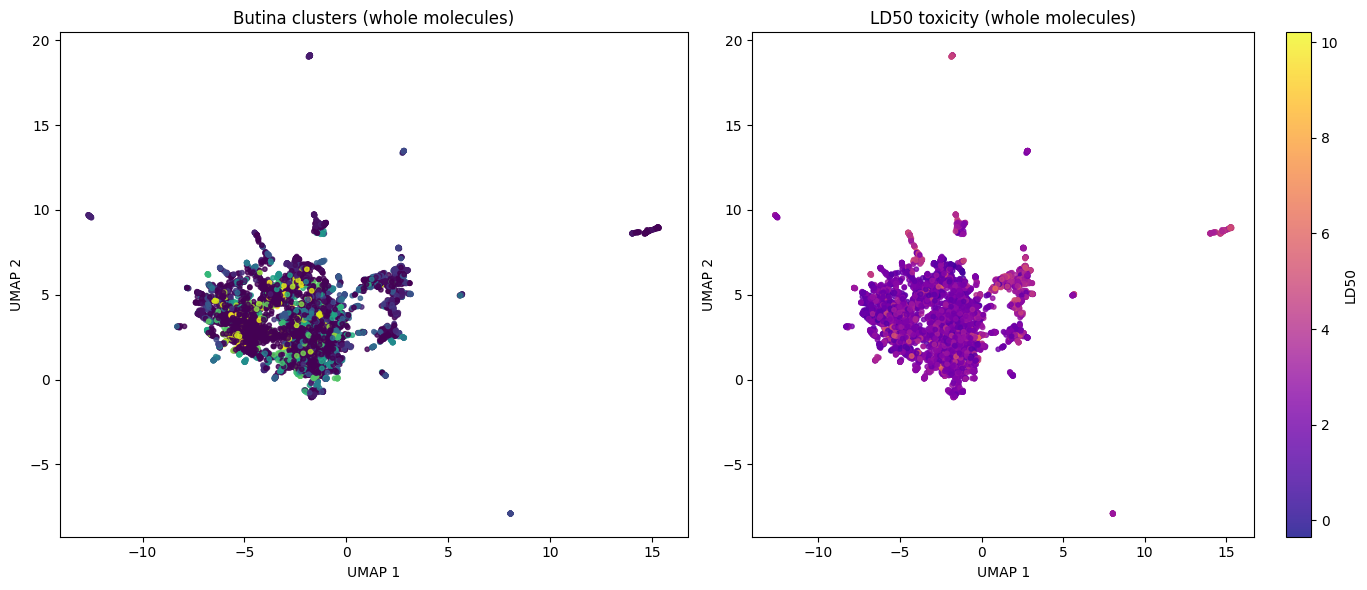

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ax1 = Chemical space and butina clustering
ax1.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=butina_labels,
    cmap="viridis",
    s=10,
    alpha=0.8
)
ax1.set(xlabel="UMAP 1", ylabel="UMAP 2")
ax1.set_title("Butina clusters (whole molecules)")

# ax2 = Chemical space and toxicity
sc = ax2.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=tox["ld_50"].values,
    cmap="plasma",
    s=10,
    alpha=0.8
)
ax2.set(xlabel="UMAP 1", ylabel="UMAP 2")
ax2.set_title("LD50 toxicity (whole molecules)")

cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label("LD50")

plt.tight_layout()
plt.show()


In [46]:
tox["scaffold_mol"] = tox["scaffold"].apply(
    lambda x: Chem.MolFromSmiles(x) if x != "NO_SCAFFOLD" else None
)

tox_scaf_fp = tox[tox["scaffold_mol"].notna()].copy()

fps_scaf = tox_scaf_fp["scaffold_mol"].apply(mol_to_fp).tolist()

len(fps_scaf)

5440

In [47]:
nfps_scaf = len(fps_scaf)

fp_array_scaf = np.zeros((nfps_scaf, 2048), dtype=int)
for i, fp in enumerate(fps_scaf):
    DataStructs.ConvertToNumpyArray(fp, fp_array_scaf[i])

fp_array_scaf.shape

(5440, 2048)

In [48]:
dists_scaf = []
cutoff_scaf = 0.6

for i in range(1, nfps_scaf):
    sims = DataStructs.BulkTanimotoSimilarity(fps_scaf[i], fps_scaf[:i])
    dists_scaf.extend([1-x for x in sims])

clusters_scaf = Butina.ClusterData(
    dists_scaf,
    nfps_scaf,
    cutoff_scaf,
    isDistData=True
)

print("Number of scaffold clusters:", len(clusters_scaf))

Number of scaffold clusters: 746


In [50]:
clusters_scaf_filtered = [c for c in clusters_scaf if len(c) >= 5]

butina_labels_scaf = np.full(nfps_scaf, -1)
for cluster_id, cluster in enumerate(clusters_scaf_filtered):
    for idx in cluster:
        butina_labels_scaf[idx] = cluster_id

sizes_scaf = [len(c) for c in clusters_scaf_filtered]

print("clusters:", len(sizes_scaf))
print("mean size:", np.mean(sizes_scaf))
print("max size:", np.max(sizes_scaf))
print("singletons:", sum(s == 1 for s in sizes_scaf))

clusters: 160
mean size: 28.425
max size: 1539
singletons: 0


In [51]:
reducer_scaf = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_emb_scaf = reducer_scaf.fit_transform(fp_array_scaf)

umap_emb_scaf.shape

c:\Users\shimo\DSA104\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(5440, 2)

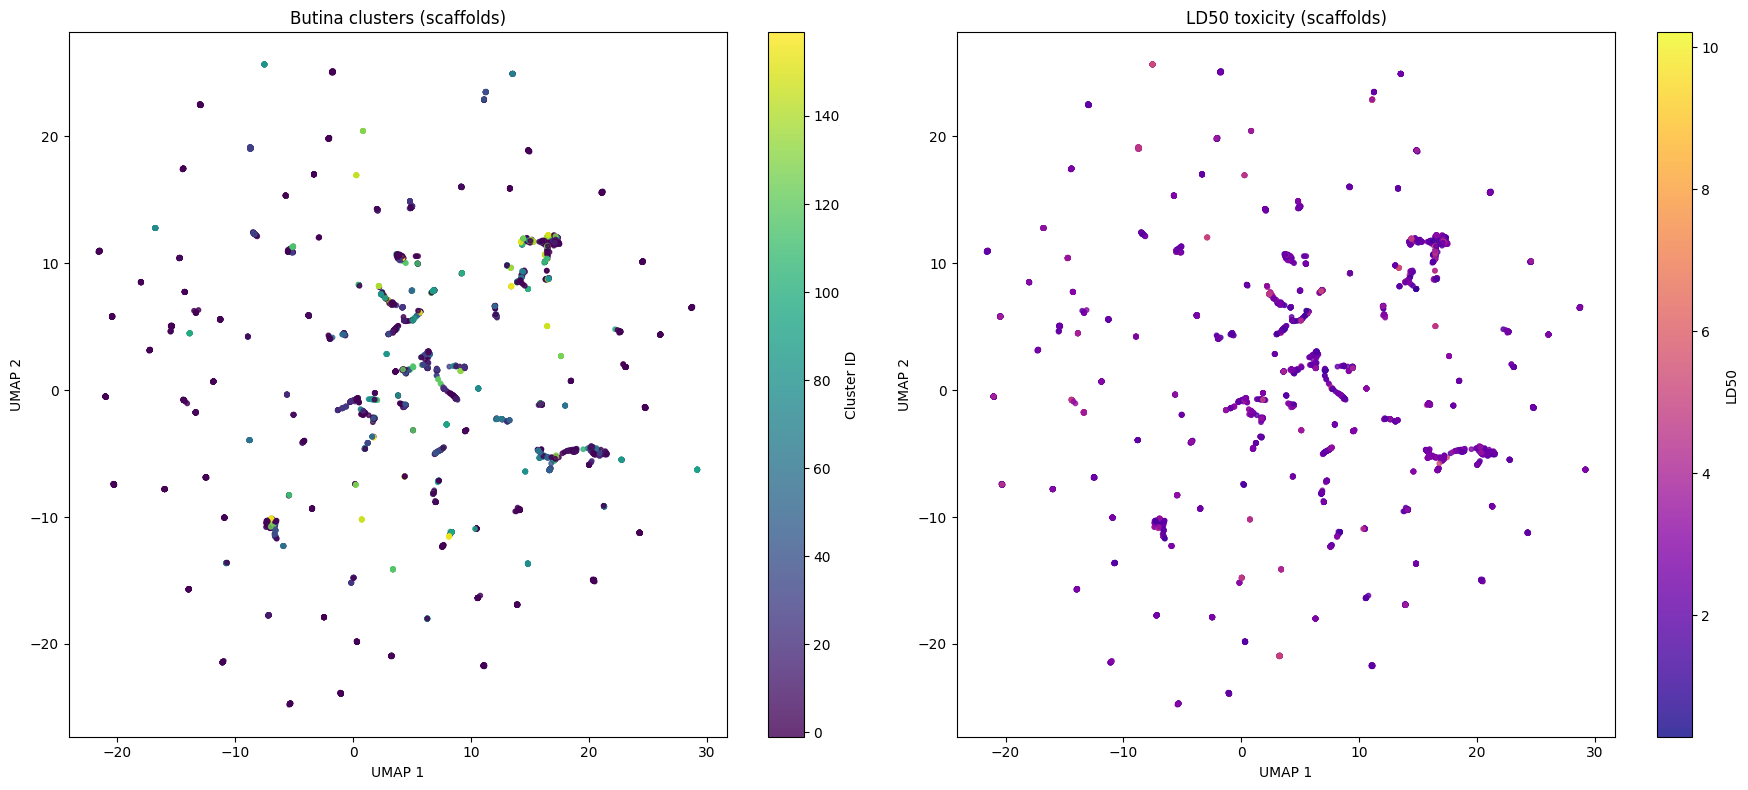

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sc1 = ax1.scatter(
    umap_emb_scaf[:,0],
    umap_emb_scaf[:,1],
    c=butina_labels_scaf,
    cmap="viridis",
    s=10,
    alpha=0.8
)
ax1.set(xlabel="UMAP 1", ylabel="UMAP 2")
ax1.set_title("Butina clusters (scaffolds)")
plt.colorbar(sc1, ax=ax1, label="Cluster ID")
sc = ax2.scatter(
    umap_emb_scaf[:,0],
    umap_emb_scaf[:,1],
    c=tox_scaf_fp["ld_50"].values,
    cmap="plasma",
    s=10,
    alpha=0.8
)
ax2.set(xlabel="UMAP 1", ylabel="UMAP 2")
ax2.set_title("LD50 toxicity (scaffolds)")

cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label("LD50")

plt.tight_layout()
plt.show()

In [59]:
best_r2 = results_df.iloc[0]["r2"]
filtered_r2 = filtered_result["r2"]

print("Before filtering R2:", best_r2)
print("After filtering R2:", filtered_r2)

if filtered_r2 > best_r2:
    print("Performance improved after filtering")
elif filtered_r2 < best_r2:
    print("Performance decreased after filtering")
else:
    print("No significant change")

Before filtering R2: 0.6197799582903203
After filtering R2: 0.6246711110391686
Performance improved after filtering


#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
2) Is the One-Hot Encoding needed in this case?
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
6) When might scaffolding prove useful?
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?


1. For me molecular descriptors performs better than scaffold only and functional group only may be because desccriptors contain more info about each molecules physicochemical properties. Scaffold only deals with core structure and ignores substituent and functional groups reduce the molecule to some predeffined motifs so they are incomplete. So the best option will be combining descriptors with scaffold and functionaal group features.

2. For scaffold it is needed to convert the categorical string into machine readable thing and for functional grops its binary so no one hot encoding is  needed .

3. there is a slight improvement . By removing highly correlated features we can reduce noise and filterng helps in reducinf feature space complexity.

4. a) Load and clean data b)Convert SMILES to molecules c)Generate features (descriptors, scaffolds, functional groups) d)Combine features e)  Apply feature filtering (optional) f)train model and evaluation g)visualization

I will convert all features into numeric format (dataframe or np array), try to encode the categorical strings and  will try to scale features if i use SVM or linear regression.



5. As scaffold only use core so the plot looks compressed and less detailed.

In terms of BUTINA and UMAP , Butina is good for precise clustering but umap is for visual representation.

6. When We want to a) focus on the core structure of the molecules b) Compare similar families of compounds c) Simplify chemical space and improve interpretation d) Drug design

7. According to me yes , as i see in UMAP  nearby points have similar level of toxicity but its not fully clear . So i will say structure solely doesnt contribute to txicity